In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


In [39]:

# reproducibility
torch.manual_seed(42)

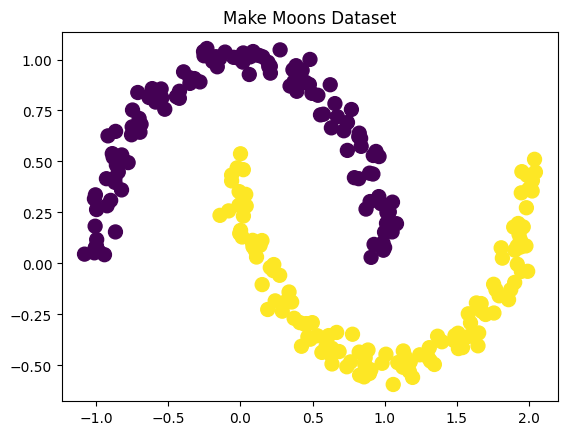

In [40]:
# =========================
# 1. Dataset
# =========================

X, y = make_moons(n_samples=250, noise=0.05, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, s=100)
plt.title("Make Moons Dataset")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [41]:
# convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
y_test = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)


In [42]:
# =========================
# 2. Model
# =========================

class SigmoidNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,1), nn.Sigmoid(),
        )

    def forward(self,x):
        return self.net(x)


model = SigmoidNet()

In [43]:
# =========================
# 3. Loss + Optimizer
# =========================

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)




In [44]:


# =========================
# 4. Save Initial Weights
# =========================

old_weights = model.net[0].weight.data.clone().numpy()

In [45]:
# for plotting weight movement
initial_weights = model.net[0].weight.data.clone()
weight_changes = []

In [46]:
# =========================
# 5. Training
# =========================

epochs = 100

for epoch in range(epochs):

    optimizer.zero_grad()

    y_pred = model(X_train)

    loss = criterion(y_pred, y_train)

    loss.backward()

    optimizer.step()

    # track weight movement
    current_weights = model.net[0].weight.data.clone()

    change = torch.mean(torch.abs(current_weights - initial_weights)).item()

    weight_changes.append(change)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss: {loss.item():.4f}")

Epoch 0 Loss: 0.6949
Epoch 10 Loss: 0.6939
Epoch 20 Loss: 0.6933
Epoch 30 Loss: 0.6930
Epoch 40 Loss: 0.6930
Epoch 50 Loss: 0.6930
Epoch 60 Loss: 0.6930
Epoch 70 Loss: 0.6929
Epoch 80 Loss: 0.6929
Epoch 90 Loss: 0.6929


In [47]:
# =========================
# 6. Save New Weights
# =========================

new_weights = model.net[0].weight.data.clone().numpy()


In [48]:

# =========================
# 7. Compute Gradient
# =========================

learning_rate = 0.001

gradient = (old_weights - new_weights) / learning_rate

percent_change = np.abs(100 * (old_weights - new_weights) / old_weights)

print("\nGradient:\n", gradient)

print("\nPercent Change:\n", percent_change)



Gradient:
 [[ 40.834217  -32.570957 ]
 [ -6.8036613  24.614511 ]
 [  0.          0.       ]
 [ 13.937472  -23.300735 ]
 [-29.284775    7.4446197]
 [  7.800638  -13.010755 ]
 [-27.33904    15.5385275]
 [ 31.865267   -7.253259 ]
 [  2.362311  -17.286098 ]
 [  0.          0.       ]]

Percent Change:
 [[ 7.5533543   5.5496206 ]
 [ 4.107111    3.789435  ]
 [ 0.          0.        ]
 [ 4.0485487   5.6109643 ]
 [ 4.6980047   1.435098  ]
 [ 1.2691921   9.83119   ]
 [ 5.233186   16.225876  ]
 [ 9.345792    7.265093  ]
 [ 0.43337312 16.539082  ]
 [ 0.          0.        ]]


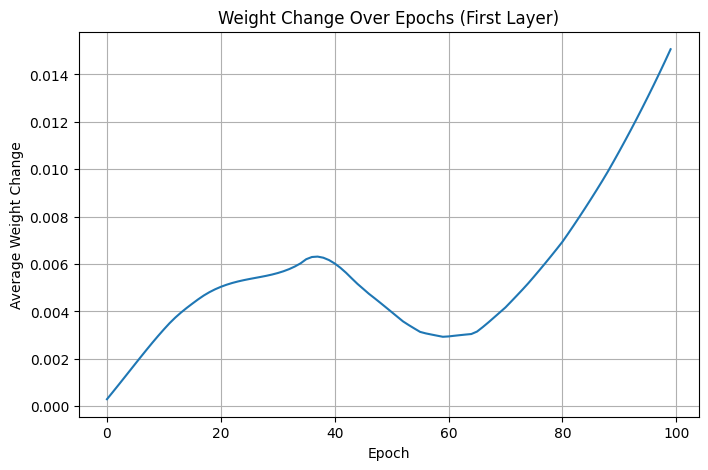

In [49]:
# =========================
# 8. Plot Weight Change
# =========================

plt.figure(figsize=(8,5))
plt.plot(weight_changes)

plt.xlabel("Epoch")
plt.ylabel("Average Weight Change")
plt.title("Weight Change Over Epochs (First Layer)")
plt.grid(True)

plt.show()